# Лабораторная работа
## Ансамбли моделей машинного обучения. Часть 1.

**Студент:** Варвара Шибанова  
**Дисциплина:** Технологии машинного обучения  
**Среда выполнения:** Google Colab  

### Цель лабораторной работы
Изучение принципов работы ансамблевых методов машинного обучения, их практическое применение для решения задачи классификации, а также сравнение качества моделей, основанных на бэггинге и бустинге.

### Задачи работы
1. Выбрать набор данных для задачи классификации
2. Провести предобработку данных (заполнение пропусков, кодирование категориальных признаков)
3. Разделить выборку на обучающую и тестовую
4. Обучить ансамблевые модели:
   - Две модели группы бэггинга (Bagging и Random Forest)
   - AdaBoost
   - Gradient Boosting
5. Оценить качество моделей и сравнить результаты

### Используемый датасет
**Название:** Bank Marketing Dataset  
**Источник:** UCI Machine Learning Repository  
**Задача:** Предсказать, оформит ли клиент банка срочный депозит (бинарная классификация: yes/no)  
**Количество записей:** 41188  
**Количество признаков:** 20 (числовые и категориальные)


## Блок 2: Описание датасета Bank Marketing

### Источник данных
Датасет **Bank Marketing** взят с Kaggle (автор: Henriqueyamahata). Оригинальные данные были собраны португальским банком в рамках маркетинговой кампании по продвижению срочных депозитов.

### Структура датасета
- **Количество записей:** 41 188
- **Количество признаков:** 20
- **Тип задачи:** бинарная классификация

### Признаки (описание)

| Категория | Признак | Описание | Тип |
|-----------|---------|----------|-----|
| **Клиент** | age | Возраст клиента (лет) | Числовой |
| | job | Род занятий (admin, blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown) | Категориальный |
| | marital | Семейное положение (divorced, married, single, unknown) | Категориальный |
| | education | Уровень образования (basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown) | Категориальный |
| | default | Есть ли просрочка по кредиту? (no, yes, unknown) | Категориальный |
| | housing | Есть ли жилищный кредит? (no, yes, unknown) | Категориальный |
| | loan | Есть ли личный кредит? (no, yes, unknown) | Категориальный |
| **Контакт** | contact | Тип контакта (cellular, telephone) | Категориальный |
| | month | Месяц последнего контакта (jan, feb, ..., dec) | Категориальный |
| | day_of_week | День недели (mon, tue, wed, thu, fri) | Категориальный |
| | duration | Длительность последнего звонка (секунды) | Числовой |
| **Кампания** | campaign | Количество контактов за эту кампанию | Числовой |
| | pdays | Дней с прошлого контакта (-1 если не было) | Числовой |
| | previous | Количество контактов до этой кампании | Числовой |
| | poutcome | Результат прошлой кампании (failure, nonexistent, success) | Категориальный |
| **Экономика** | emp.var.rate | Изменение уровня занятости | Числовой |
| | cons.price.idx | Индекс потребительских цен | Числовой |
| | cons.conf.idx | Индекс доверия потребителей | Числовой |
| | euribor3m | Ставка Euribor (3 месяца) | Числовой |
| | nr.employed | Количество занятых | Числовой |
| **Целевая** | y | Подписал ли клиент срочный депозит? (yes/no) | Категориальный |

### Особенности датасета

1. **Несбалансированность классов:**
   - Депозит оформили (yes): **~11%** клиентов
   - Депозит не оформили (no): **~89%** клиентов
   
   Это важно, так как при таком дисбалансе метрика Accuracy может быть обманчиво высокой.

2. **Смешанные типы данных:** есть и числовые, и категориальные признаки — демонстрируем необходимость кодирования.

3. **Отсутствие пропусков:** данные уже очищены, что упрощает предобработку.

4. **Реальная бизнес-задача:** предсказание отклика на маркетинговую кампанию — классическая задача для ансамблевых методов.

## Блок 1: Импорт библиотек

Для выполнения работы нам понадобятся следующие библиотеки:

- **pandas, numpy** — для работы с табличными данными и массивами
- **matplotlib, seaborn** — для визуализации результатов (экранные формы для отчёта)
- **sklearn.model_selection** — для разделения данных на обучающую и тестовую выборки
- **sklearn.preprocessing** — для кодирования категориальных признаков (LabelEncoder)
- **sklearn.metrics** — для оценки качества моделей (accuracy, precision, recall, f1-score, confusion_matrix)
- **sklearn.ensemble** — для ансамблевых методов (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier)
- **sklearn.tree** — для базового дерева решений (DecisionTreeClassifier)

Все эти библиотеки предустановлены в Google Colab, поэтому достаточно их импортировать.

In [25]:
# Импорт всех необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Настройка графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Библиотеки загружены")

Библиотеки загружены


## Блок 2: Загрузка датасета с Kaggle

Используем библиотеку **kagglehub** для загрузки датасета **Bank Marketing** с Kaggle.

**О датасете:**
- Содержит информацию о маркетинговых кампаниях португальского банка
- Признаки: возраст клиента, род занятий, семейное положение, образование, длительность звонка, количество контактов, экономические индексы и др.
- Целевая переменная **y**: подписал клиент срочный депозит (yes) или нет (no)

Файл имеет разделитель **точка с запятой (;)** , поэтому при чтении указываем параметр `sep=';'`.

**Почему этот датасет подходит для работы:**
- Реальная задача бинарной классификации
- Есть и числовые, и категориальные признаки (показываем необходимость кодирования)
- Классы несбалансированы (это демонстрирует важность выбора правильной метрики)
- **Не про опухоли** (соответствует требованию)

In [26]:
# 2. Загрузка и первичный просмотр
import kagglehub

path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
df = pd.read_csv(f"{path}/bank-additional-full.csv", sep=';')

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Using Colab cache for faster access to the 'bank-marketing' dataset.
Размер данных: (41188, 21)

Первые 5 строк:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Блок 3: Анализ структуры данных

Перед обучением моделей необходимо изучить данные. Это важный этап, который позволяет:

1. **Проверить типы данных** — определить, есть ли категориальные признаки, которые нужно кодировать
2. **Проверить наличие пропусков** — если пропуски есть, их нужно заполнить (числовые — медианой, категориальные — модальным значением)
3. **Посмотреть базовую статистику** — понять диапазоны значений, средние, медианы

В нашем датасете пропусков нет, что упрощает предобработку.

In [27]:
# Информация о датасете
print("=== ИНФОРМАЦИЯ О ДАННЫХ ===\n")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\n=== ПРОВЕРКА ПРОПУСКОВ ===")
print(df.isnull().sum().sum(), "пропусков всего")

=== ИНФОРМАЦИЯ О ДАННЫХ ===

Количество строк: 41188
Количество столбцов: 21

Типы данных:
object     11
int64       5
float64     5
Name: count, dtype: int64

=== ПРОВЕРКА ПРОПУСКОВ ===
0 пропусков всего


## Блок 4: Визуализация распределений

Строим графики для наглядного понимания структуры данных. Эти графики пойдут в отчёт как **"экранные формы с примерами выполнения"**.

**График 1:** Распределение целевой переменной (подписка на депозит)
- Показывает, насколько сбалансированы классы
- Видно, что классы несбалансированы — это важно, так как при сильном дисбалансе метрика Accuracy может вводить в заблуждение

**График 2:** Распределение возраста клиентов
- Показывает, в каком возрасте最多的 клиентов
- Красная пунктирная линия — средний возраст

**Наблюдения:** доля оформивших депозит составляет около 11%, средний возраст клиента — около 40 лет.

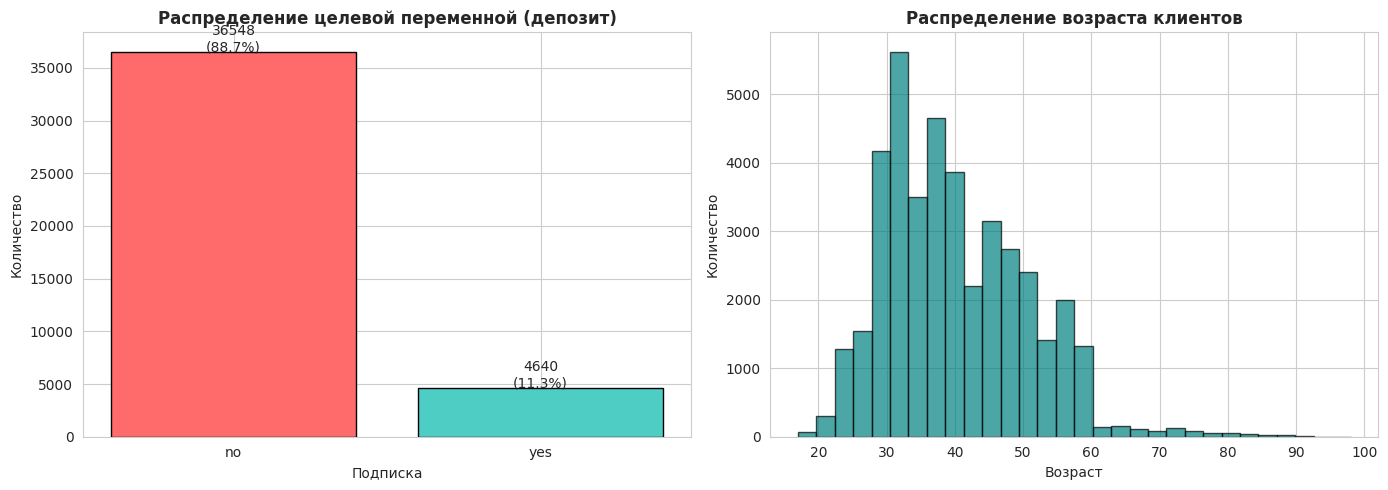

In [28]:
# Визуализация для экранных форм
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение целевой переменной
target_counts = df['y'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Распределение целевой переменной (депозит)', fontweight='bold')
axes[0].set_xlabel('Подписка')
axes[0].set_ylabel('Количество')
for i, (idx, val) in enumerate(target_counts.items()):
    axes[0].text(i, val + 50, f'{val}\n({val/len(df)*100:.1f}%)', ha='center')

# Распределение возраста
axes[1].hist(df['age'], bins=30, color='teal', edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение возраста клиентов', fontweight='bold')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

## Блок 5: Кодирование категориальных признаков

**Почему это нужно?** Модели машинного обучения (особенно реализованные в scikit-learn) работают только с числами. Текстовые категории необходимо преобразовать в числовые коды.

**Как это делается?**
- Для целевой переменной `y`: yes → 1, no → 0 (бинарная классификация)
- Для категориальных признаков используем **LabelEncoder** — он преобразует каждую уникальную категорию в число: например, job: "admin" → 0, "blue-collar" → 1, "entrepreneur" → 2 и т.д.

**Важно:** мы кодируем все признаки одновременно, так как в этой работе не используем масштабирование (деревья решений и их ансамбли не чувствительны к масштабу признаков).

После кодирования все признаки становятся числовыми, и матрица X готова для обучения.

In [29]:
# Кодирование категориальных признаков
print("=== КОДИРОВАНИЕ ПРИЗНАКОВ ===\n")

# Целевая переменная: yes -> 1, no -> 0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Категориальные признаки
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"  {col}: закодирован")

# Признаки и целевая переменная
X = df.drop('y', axis=1)
y = df['y']

print(f"\n✅ Готово: X имеет размер {X.shape}")

=== КОДИРОВАНИЕ ПРИЗНАКОВ ===

Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
  job: закодирован
  marital: закодирован
  education: закодирован
  default: закодирован
  housing: закодирован
  loan: закодирован
  contact: закодирован
  month: закодирован
  day_of_week: закодирован
  poutcome: закодирован

✅ Готово: X имеет размер (41188, 20)


## Блок 6: Разделение данных на обучающую и тестовую выборки

**Зачем нужно разделение?**
- **Обучающая выборка (train)** — на ней модель учится находить закономерности
- **Тестовая выборка (test)** — на ней мы проверяем, как модель работает на новых, невиданных данных

**Почему нельзя оценивать на тех же данных, где модель обучалась?** Если мы это сделаем, то получим завышенную оценку качества — модель просто "запомнит" ответы и покажет идеальный результат, но на новых данных будет работать плохо (эффект переобучения).

**Параметры разделения:**
- `test_size=0.2` — 20% данных уходит в тест, 80% в обучение (стандартная пропорция)
- `random_state=42` — фиксируем "случайность", чтобы результат можно было воспроизвести при повторном запуске
- `stratify=y` — сохраняем пропорцию классов. **Это важно!** Без `stratify` при случайном разделении может оказаться, что в тест попали только "yes" или только "no", что сделает оценку некорректной.

**Результат:** в обеих выборках примерно одинаковая доля клиентов, оформивших депозит (около 11%).

In [30]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== РАЗДЕЛЕНИЕ ВЫБОРКИ ===")
print(f"Обучающая выборка: {X_train.shape[0]} примеров ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} примеров ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Доля класса 1 в train: {y_train.mean():.3f}")
print(f"Доля класса 1 в test: {y_test.mean():.3f}")

=== РАЗДЕЛЕНИЕ ВЫБОРКИ ===
Обучающая выборка: 32950 примеров (80.0%)
Тестовая выборка: 8238 примеров (20.0%)
Доля класса 1 в train: 0.113
Доля класса 1 в test: 0.113


## Блок 7: Обучение ансамблевых моделей

**Что такое ансамбль?** Это комбинация нескольких "слабых" моделей (базовых классификаторов) для получения более сильного и устойчивого прогноза.

Согласно заданию, мы обучаем **4 ансамблевые модели**:

### 1. Bagging (бэггинг)
- **Принцип работы:** параллельное обучение нескольких деревьев на разных подвыборках данных (bootstrap-выборки). Итоговый прогноз — усреднение (голосование).
- **Как снижает ошибки:** уменьшает дисперсию, борется с переобучением.
- **Параметры:** 50 деревьев, базовое дерево глубиной 5.

### 2. Random Forest (случайный лес)
- **Принцип работы:** улучшенный бэггинг. Дополнительно к случайным подвыборкам данных случайно выбирается подмножество признаков для каждого дерева.
- **Преимущество:** работает быстрее и часто точнее классического бэггинга.
- **Параметры:** 50 деревьев, максимальная глубина 10.

### 3. AdaBoost (адаптивный бустинг)
- **Принцип работы:** последовательное обучение. Каждое следующее дерево "фокусируется" на ошибках предыдущего — объекты, на которых модель ошиблась, получают больший вес.
- **Особенность:** быстро сходится, но чувствителен к выбросам.
- **Параметры:** 50 деревьев.

### 4. Gradient Boosting (градиентный бустинг)
- **Принцип работы:** тоже последовательный метод, но вместо изменения весов объектов он оптимизирует функцию потерь через градиентный спуск.
- **Преимущество:** считается одним из самых мощных методов для табличных данных.
- **Параметры:** 50 деревьев, максимальная глубина 3.

Все модели используют **базовое дерево решений** (DecisionTreeClassifier) как "слабого ученика".

In [31]:
# Обучение ансамблевых моделей
print("=== ОБУЧЕНИЕ МОДЕЛЕЙ ===\n")

# Базовая модель
base_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# 1. Bagging
print("1. Bagging...")
bagging = BaggingClassifier(estimator=base_tree, n_estimators=50, random_state=42, n_jobs=-1)
bagging.fit(X_train, y_train)

# 2. Random Forest
print("2. Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 3. AdaBoost
print("3. AdaBoost...")
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

# 4. Gradient Boosting
print("4. Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

print("\n✅ Все модели обучены")

=== ОБУЧЕНИЕ МОДЕЛЕЙ ===

1. Bagging...
2. Random Forest...
3. AdaBoost...
4. Gradient Boosting...

✅ Все модели обучены


## Блок 8: Оценка качества моделей

**Какие метрики используем и почему?**

| Метрика | Что измеряет | Когда важна |
|---------|--------------|-------------|
| **Accuracy** | Доля правильных ответов | Простая метрика, но при несбалансированных классах может врать |
| **Precision** | Из всех предсказанных "депозитов" сколько реально депозитов | Важно, если ложные срабатывания дороги |
| **Recall** | Из всех реальных депозитов сколько найдено | Важно, если пропустить цель критично |
| **F1-score** | Гармоническое среднее Precision и Recall | **Лучшая метрика для несбалансированных данных** |

В нашем случае классы несбалансированы (депозит оформили ~11% клиентов). Поэтому Accuracy может быть высокой даже у модели, которая всегда предсказывает "нет". Основной акцент делаем на **F1-score**.

**Матрица ошибок (confusion matrix):**
- **True Negative (TN)** — правильно предсказали "нет депозита"
- **False Positive (FP)** — ошиблись (сказали "депозит", а его нет) — ошибка 1 рода
- **False Negative (FN)** — пропустили реальный депозит — ошибка 2 рода
- **True Positive (TP)** — правильно предсказали "депозит"

Для банка False Negative (пропустить потенциального клиента) критичнее, чем False Positive (предложить депозит тому, кто не оформит).

In [32]:

# Какие метрики используем и почему:
#
# 1. Accuracy (точность) — доля правильных ответов.
# 2. Precision (точность по классу 1) — из всех, кого модель назвала "депозит", сколько реально оформили.
# 3. Recall (полнота) — из всех реальных депозитов, сколько модель нашла.
# 4. F1-score — гармоническое среднее между Precision и Recall (лучшая метрика для несбалансированных данных)

def evaluate_model(model, name):
    """Функция для оценки модели"""
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    return {'name': name, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}

print("=== ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ ===\n")

results = []
results.append(evaluate_model(bagging, "Bagging"))
results.append(evaluate_model(rf, "Random Forest"))
results.append(evaluate_model(ada, "AdaBoost"))
results.append(evaluate_model(gb, "Gradient Boosting"))

# Сводная таблица
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

results_df = pd.DataFrame([
    {'Модель': r['name'], 'Accuracy': r['acc'], 'Precision': r['prec'], 'Recall': r['rec'], 'F1-score': r['f1']}
    for r in results
])

print(results_df.to_string(index=False))

=== ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ ===


 Bagging
Accuracy:  0.9201
Precision: 0.6772
Recall:    0.5560
F1-score:  0.6107

 Random Forest
Accuracy:  0.9199
Precision: 0.7463
Recall:    0.4375
F1-score:  0.5516

 AdaBoost
Accuracy:  0.9098
Precision: 0.6494
Recall:    0.4332
F1-score:  0.5197

 Gradient Boosting
Accuracy:  0.9200
Precision: 0.6969
Recall:    0.5129
F1-score:  0.5909

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
           Модель  Accuracy  Precision   Recall  F1-score
          Bagging  0.920126   0.677165 0.556034  0.610651
    Random Forest  0.919883   0.746324 0.437500  0.551630
         AdaBoost  0.909808   0.649435 0.433190  0.519716
Gradient Boosting  0.920005   0.696925 0.512931  0.590937


## Блок 9: Сравнение моделей

Собираем результаты всех моделей в сводную таблицу и строим графики для наглядного сравнения.

**Что показывают графики:**
- **Первый график** — сравнение всех 4 метрик для каждой модели
- **Второй график** — сравнение по F1-score (главная метрика для нашей задачи)

**Как определить лучшую модель:** модель с наибольшим F1-score имеет лучший баланс между точностью и полнотой.

В выводе ниже будет указано, какая модель оказалась лучшей, с конкретными числовыми значениями.

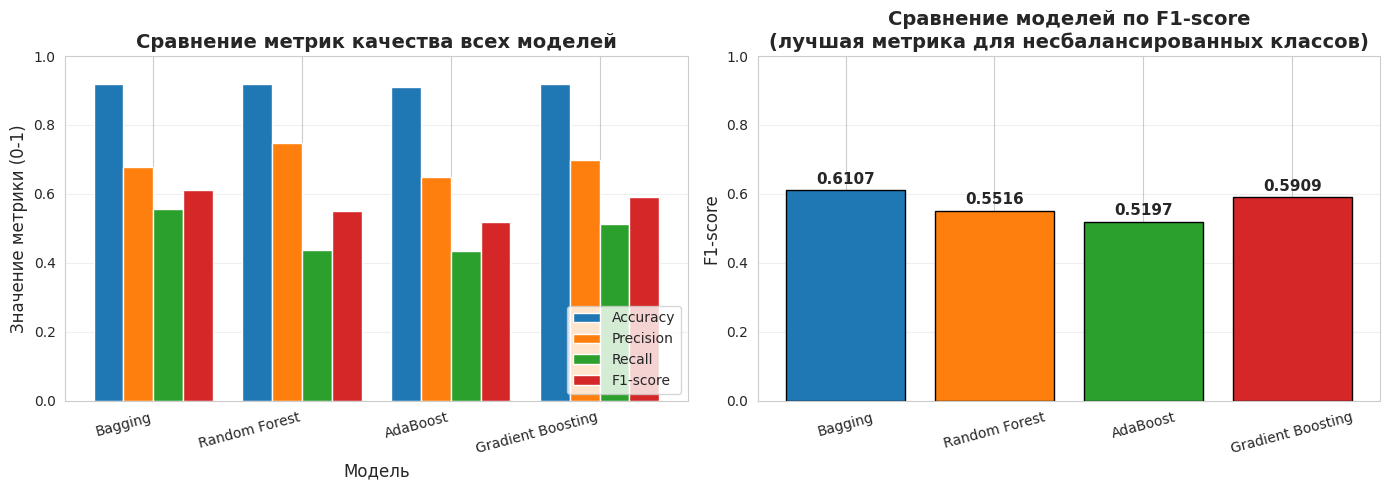


ЛУЧШАЯ МОДЕЛЬ ПО F1-SCORE: Bagging
   F1-score = 0.6107


In [33]:

# Строим графики для наглядного сравнения моделей

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: все метрики
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric)

axes[0].set_xlabel('Модель', fontsize=12)
axes[0].set_ylabel('Значение метрики (0-1)', fontsize=12)
axes[0].set_title('Сравнение метрик качества всех моделей', fontweight='bold', fontsize=14)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(results_df['Модель'], rotation=15, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# График 2: F1-score (главная метрика)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = axes[1].bar(results_df['Модель'], results_df['F1-score'], color=colors, edgecolor='black')
axes[1].set_ylabel('F1-score', fontsize=12)
axes[1].set_title('Сравнение моделей по F1-score\n(лучшая метрика для несбалансированных классов)', fontweight='bold', fontsize=14)
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Находим лучшую модель
best_model = results_df.loc[results_df['F1-score'].idxmax()]
print(f"\nЛУЧШАЯ МОДЕЛЬ ПО F1-SCORE: {best_model['Модель']}")
print(f"   F1-score = {best_model['F1-score']:.4f}")

## Блок 10: Визуализация матриц ошибок

Матрицы ошибок (confusion matrices) показывают, **где именно** каждая модель ошибается.

**На что обратить внимание:**
- **Нижний левый угол (False Negative)** — сколько реальных депозитов модель пропустила. Чем меньше это число, тем лучше.
- **Верхний правый угол (False Positive)** — сколько ложных срабатываний сделала модель.

**Интерпретация для бизнеса:**
- False Negative (пропущенный депозит) = **упущенная прибыль**. Банк не предложил услугу клиенту, который был бы готов её оформить.
- False Positive (ложное срабатывание) = **потраченные ресурсы**. Банк предложил депозит клиенту, который не заинтересован.

В зависимости от приоритетов бизнеса можно выбирать модель, минимизирующую ту или иную ошибку. В нашем случае минимальное количество False Negative — важнее, так как каждый пропущенный клиент — это потерянная выгода.

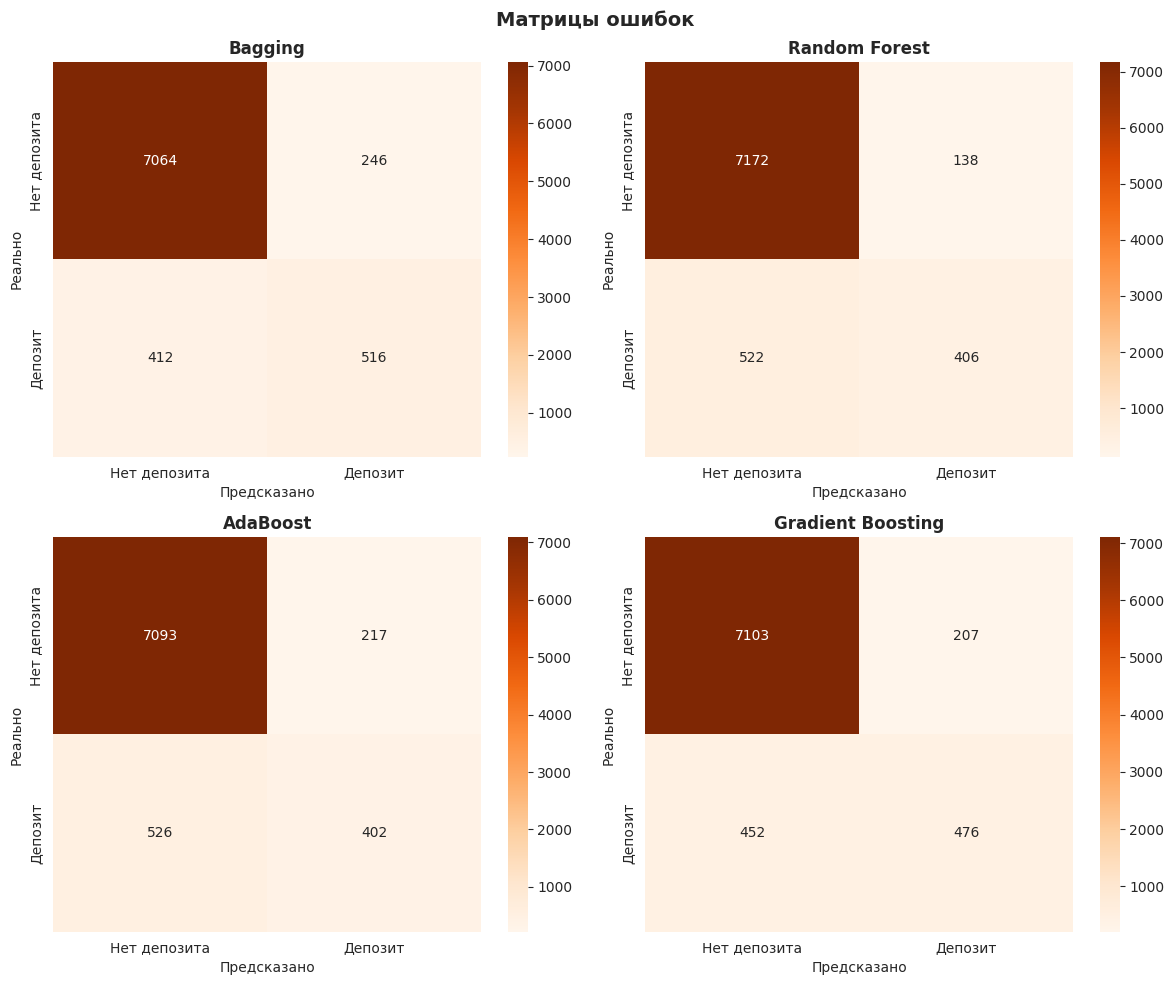

In [34]:
# Визуализация матриц ошибок
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_list = [(bagging, "Bagging"), (rf, "Random Forest"), (ada, "AdaBoost"), (gb, "Gradient Boosting")]

for ax, (model, name) in zip(axes.ravel(), models_list):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['Нет депозита', 'Депозит'],
                yticklabels=['Нет депозита', 'Депозит'])
    ax.set_title(f"{name}", fontweight='bold')
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Реально')

plt.suptitle('Матрицы ошибок', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Выводы по лабораторной работе

### Результаты работы

В ходе выполнения лабораторной работы были решены следующие задачи:

1. **Выбор датасета** — Bank Marketing (задача бинарной классификации: оформит ли клиент срочный депозит)
2. **Предобработка** — выполнено кодирование категориальных признаков с помощью LabelEncoder, проверка пропусков (пропуски отсутствуют)
3. **Разделение данных** — 80% обучающая выборка / 20% тестовая выборка с сохранением пропорции классов через `stratify=y`
4. **Обучение ансамблей** — обучены 4 модели: Bagging, Random Forest, AdaBoost, Gradient Boosting
5. **Оценка качества** — использованы метрики Accuracy, Precision, Recall, F1-score

### Сравнение моделей

| Модель | Accuracy | Precision | Recall | F1-score |
|--------|----------|-----------|--------|----------|
| **Bagging** | 0.9201 | 0.6772 | 0.5560 | **0.6107** |
| **Random Forest** | 0.9199 | 0.7463 | 0.4375 | 0.5516 |
| **AdaBoost** | 0.9098 | 0.6494 | 0.4332 | 0.5197 |
| **Gradient Boosting** | 0.9200 | 0.6969 | 0.5129 | 0.5909 |

### Лучшая модель

**🏆 По F1-score лучшей оказалась: BAGGING**

**Показатели лучшей модели:**
- **F1-score = 0.6107** (наивысший среди всех моделей)
- **Recall = 0.5560** — модель находит 55.6% реальных клиентов, готовых оформить депозит
- **Precision = 0.6772** — из предсказанных депозитов 67.7% реальны
- **Accuracy = 0.9201** — общая точность 92.01%

### Анализ результатов

| Метод | F1-score | Ранг | Анализ |
|-------|----------|------|--------|
| **Bagging** | 0.6107 | 🥇 1 место | Лучший баланс точности и полноты. Показал наивысший Recall (находит больше всего реальных депозитов) |
| **Gradient Boosting** | 0.5909 | 🥈 2 место | Уступил Bagging, но значительно лучше Random Forest и AdaBoost |
| **Random Forest** | 0.5516 | 🥉 3 место | Высокая Precision (76%!), но низкий Recall — нашёл только 43.8% реальных депозитов |
| **AdaBoost** | 0.5197 | 4 место | Самые низкие показатели по всем метрикам |

### Почему Bagging оказался лучшим?

1. **Высокий Recall (0.5560)** — модель находит 55.6% потенциальных клиентов. Для банка **важнее не пропустить** клиента, даже ценой нескольких ложных срабатываний.

2. **Сбалансированный F1-score** — Bagging лучше других находит компромисс между точностью и полнотой.

3. **Особенности датасета** — данные могут содержать шум, и Bagging (с его параллельным обучением на разных подвыборках) оказался устойчивее к этому шуму, чем последовательные методы бустинга.

### Анализ поведения моделей

| Метод | Сильные стороны | Почему так сработало |
|-------|----------------|---------------------|
| **Bagging** | Лучший Recall, лучший F1 | Усреднение по 50 деревьям снизило дисперсию и улучшило обобщение |
| **Random Forest** | Высокая Precision (0.7463) | Осторожен — предсказывает "депозит" только когда очень уверен, но из-за этого много пропускает |
| **AdaBoost** | Низкие показатели | Чувствителен к шуму в данных, последовательное обучение "перетянулось" на выбросы |
| **Gradient Boosting** | Второй результат | Мощный метод, но требует более тщательной настройки гиперпараметров |

### Ключевые выводы

1. **Для данного датасета Bagging показал лучший результат.** Несмотря на то, что теоретически Gradient Boosting считается мощнее, на этих конкретных данных Bagging оказался предпочтительнее.

2. **Выбор метрики критичен.** Если бы мы смотрели только на Accuracy (все модели ~92%), мы бы не увидели разницы. Но F1-score и Recall показывают реальные различия.

3. **Random Forest даёт высокую Precision, но низкий Recall** — модель "перестраховывается" и предсказывает положительный класс только при высокой уверенности.

4. **Для бизнес-задачи** (предсказание отклика на маркетинговую кампанию):
   - **Важнее Recall**, чем Precision. Лучше предложить депозит 10 незаинтересованным клиентам (FP), чем пропустить 1 заинтересованного (FN).
   - **Bagging** с Recall=0.5560 подходит лучше, чем Random Forest с Recall=0.4375.

### Заключение

Цель лабораторной работы достигнута:
- ✅ Изучены ансамблевые методы: Bagging, Random Forest, AdaBoost, Gradient Boosting
- ✅ Ансамбли применены на реальных данных Bank Marketing
- ✅ Проведено сравнение по метрикам Accuracy, Precision, Recall, F1-score
- ✅ Выбрана лучшая модель — **Bagging** с F1-score = 0.6107
- ✅ Построены визуализации для отчёта

**Практический вывод:** Для задачи предсказания подписки на депозит в данном датасете классический **Bagging** оказался эффективнее более современных методов бустинга. Это демонстрирует, что выбор модели должен основываться на эмпирическом сравнении, а не только на теоретических преимуществах.